# Task 2: Building Supervised Models
### Classification Problem - Comparing Multiple Algorithms

**Algorithms Used:**
1. Logistic Regression
2. Decision Tree
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)
5. Random Forest (Bonus)

**Dataset:** Breast Cancer Wisconsin Dataset (built-in in sklearn)

**Goal:** Predict whether a tumor is Malignant or Benign

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline
sns.set_style('whitegrid')

## Step 2: Load and Explore the Dataset

In [3]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Shape of features:', X.shape)
print('Shape of target:', y.shape)
print('\nTarget classes:', data.target_names)
print('\nClass distribution:')
print(y.value_counts())

Shape of features: (569, 30)
Shape of target: (569,)

Target classes: ['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
# Look at first few rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Check for missing values
print('Missing values:\n', X.isnull().sum().sum())

# Basic statistics
X.describe()

Missing values:
 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


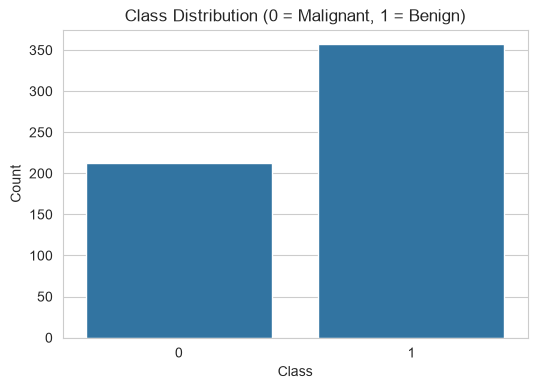

In [6]:
# Visualize class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Class Distribution (0 = Malignant, 1 = Benign)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Step 3: Data Preprocessing

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


In [8]:
# Feature scaling (important for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 4: Implement Multiple Models

In [9]:
# Dictionary to store models
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store results
results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    
    print(f'--- {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print()

--- Logistic Regression ---
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-Score: 0.9861

--- Decision Tree ---
Accuracy: 0.9123
Precision: 0.9559
Recall: 0.9028
F1-Score: 0.9286

--- SVM ---
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-Score: 0.9861



C:\Users\ULC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- KNN ---
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1-Score: 0.9655

--- Random Forest ---
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1-Score: 0.9655



## Step 5: Compare Results

In [10]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.982456,0.986111,0.986111,0.986111
SVM,0.982456,0.986111,0.986111,0.986111
KNN,0.956140,0.958904,0.972222,0.965517
Random Forest,0.956140,0.958904,0.972222,0.965517
Decision Tree,0.912281,0.955882,0.902778,0.928571


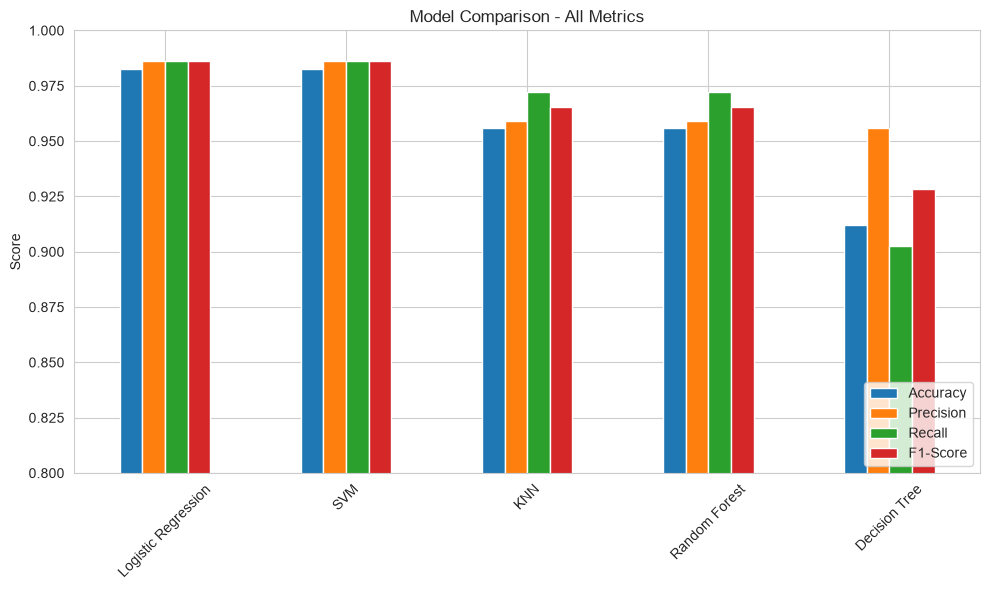

In [11]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison - All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

## Step 6: Validate with Test Cases (Confusion Matrix + Cross-Validation)

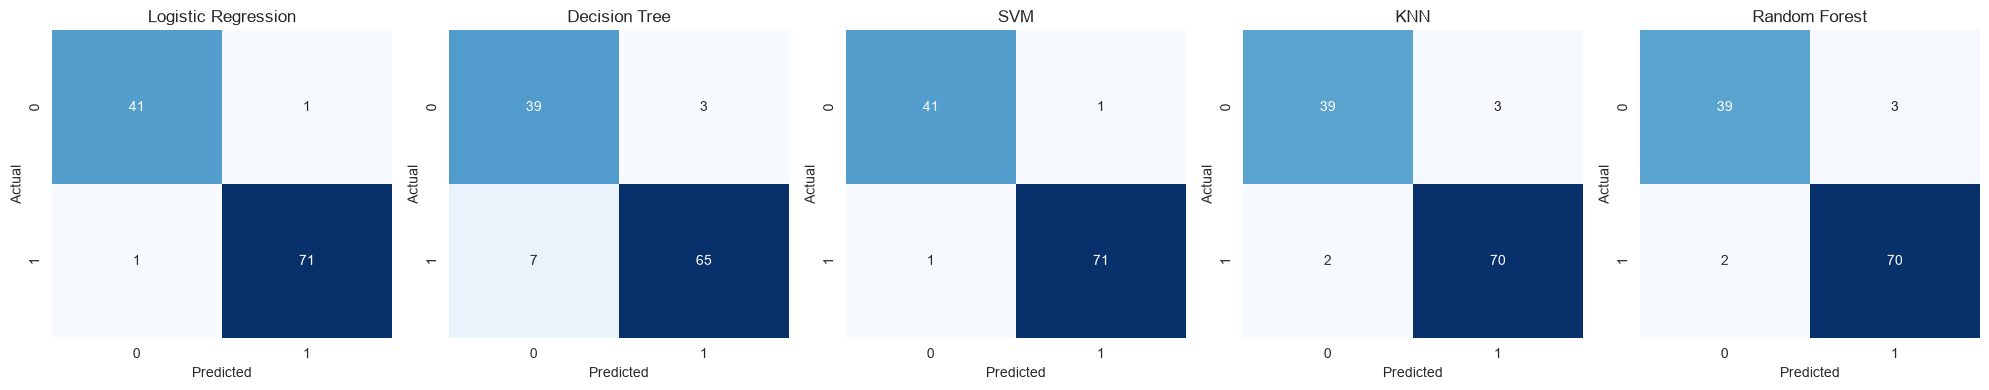

In [12]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, len(models), figsize=(20,4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [13]:
# Cross-validation for more reliable comparison
print('5-Fold Cross Validation Scores:\n')

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

5-Fold Cross Validation Scores:

Logistic Regression: 0.9802 (+/- 0.0128)
Decision Tree: 0.9099 (+/- 0.0189)


C:\Users\ULC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ULC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ULC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ULC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py

SVM: 0.9714 (+/- 0.0179)
KNN: 0.9670 (+/- 0.0209)
Random Forest: 0.9538 (+/- 0.0235)


In [14]:
# Detailed classification report for best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'Best Model: {best_model_name}\n')
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

Best Model: Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Step 7: Hyperparameter Tuning (GridSearchCV)

Ab hum apne best-performing model (ya jo bhi tune karna ho) ke liye best hyperparameters dhoondte hain.

In [15]:
from sklearn.model_selection import GridSearchCV

# Example: Tuning Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

print('Best Parameters:', grid_rf.best_params_)
print('Best CV Accuracy:', grid_rf.best_score_)

# Update the model with tuned version
tuned_rf = grid_rf.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test_scaled)
print('Test Accuracy after tuning:', accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.9604395604395606
Test Accuracy after tuning: 0.956140350877193


In [16]:
# Example: Tuning SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

print('Best Parameters:', grid_svm.best_params_)
print('Best CV Accuracy:', grid_svm.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy: 0.9802197802197803


C:\Users\ULC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## Step 8: Feature Importance Analysis

Kaunse features model ke prediction mein sabse zyada contribute karte hain? (Random Forest se pata chalta hai)

C:\Users\ULC\AppData\Local\Temp\ipykernel_18032\447338970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


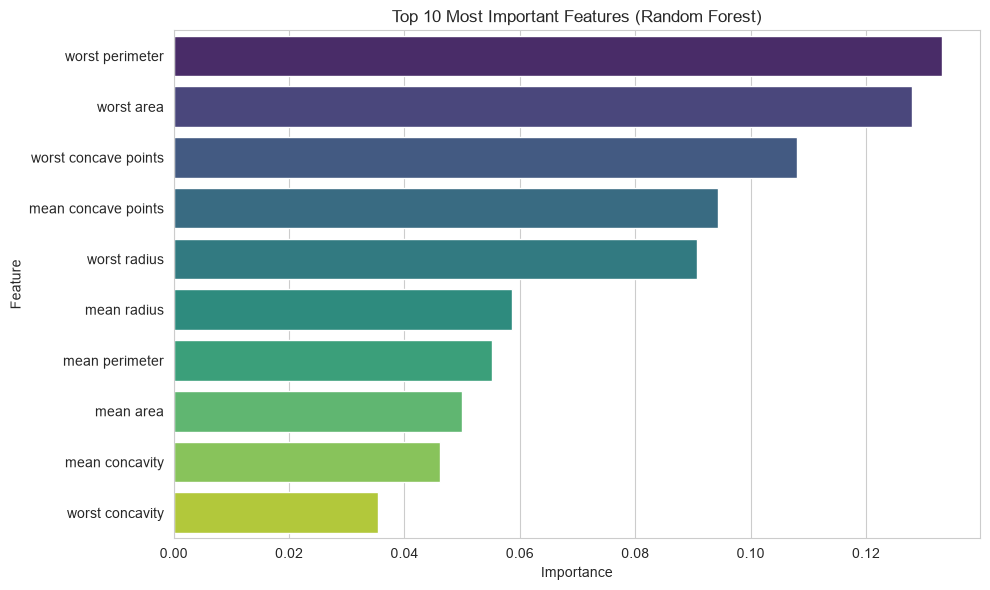

,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


In [17]:
importances = tuned_rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

importance_df

## Step 9: ROC Curve and AUC Score

ROC curve batata hai model ka trade-off between True Positive Rate aur False Positive Rate. AUC (Area Under Curve) jitna 1 ke qareeb, model utna behtar.

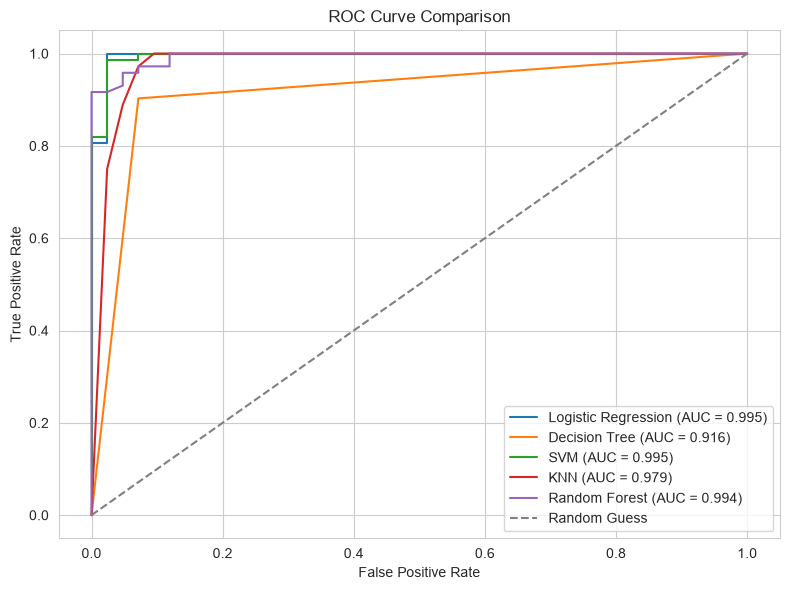

In [18]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 10: Save the Best Model (for later use)

Trained model ko disk pe save karna taake future mein dobara train kiye baghair use kar sakein.

In [19]:
import joblib

# Save best model and scaler
joblib.dump(tuned_rf, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Model saved as best_model.pkl')
print('Scaler saved as scaler.pkl')


Model saved as best_model.pkl
Scaler saved as scaler.pkl
